# Car Selling Price Prediction using Machine Learning
This notebook builds ML models to predict the selling price of cars based on features like fuel type, kilometers driven, showroom price, seller type, transmission type, number of owners, and car age.

## 1. Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


## 2. Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\ganes\Desktop\ShadowFox\car.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Dataset Information

In [4]:

print("Dataset Shape:", df.shape)
df.info()
df.describe()


Dataset Shape: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 4. Check Missing Values

In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## 5. Exploratory Data Analysis

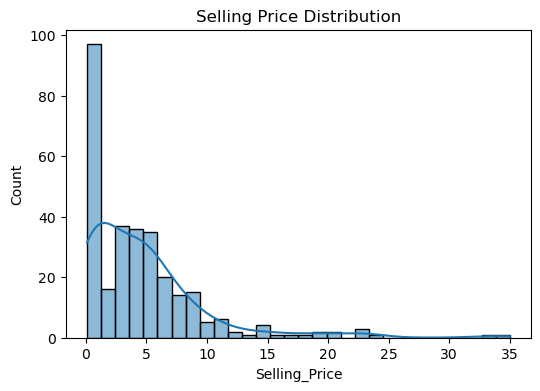

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["Selling_Price"], bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.show()

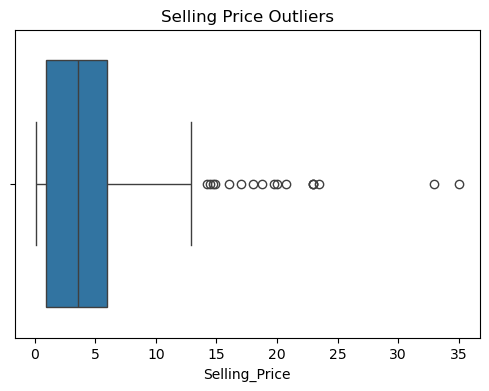

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Selling_Price"])
plt.title("Selling Price Outliers")
plt.show()

## 6. Drop Unnecessary Column

In [8]:

df.drop(["Car_Name"], axis=1, inplace=True)


## 7. Feature Engineering (Create Car Age)

In [9]:

df["Car_Age"] = 2026 - df["Year"]
df.drop(["Year"], axis=1, inplace=True)


## 8. Correlation Heatmap

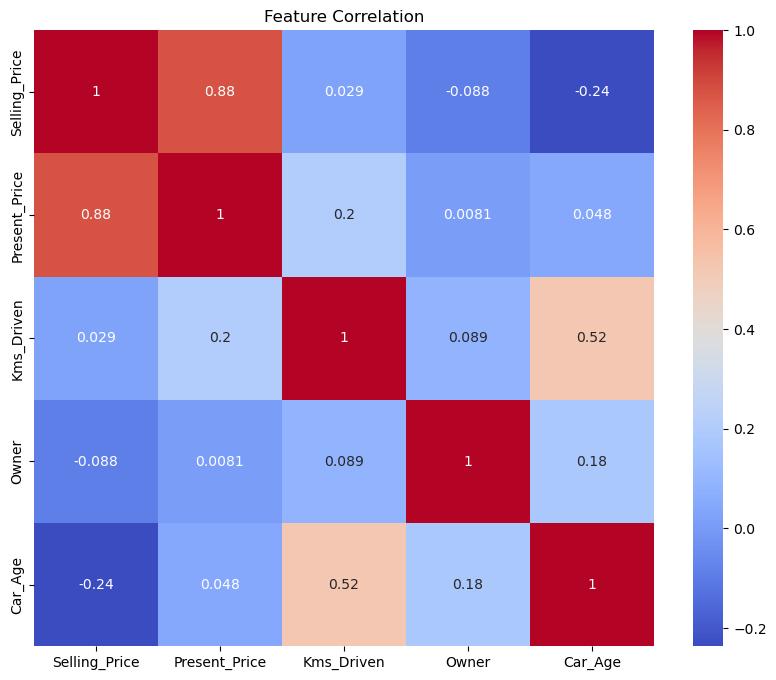

In [10]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


## 9. Convert Categorical Variables

In [11]:

df = pd.get_dummies(df, drop_first=True)
df.head()


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## 10. Define Features and Target

In [12]:

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]


## 11. Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 12. Linear Regression Model

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))


Linear Regression Results
MAE: 1.2162256821297004
MSE: 3.4788039706378724
R2: 0.8489813024899079


## 13. Decision Tree Model

In [15]:

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("MSE:", mean_squared_error(y_test, pred_dt))
print("R2:", r2_score(y_test, pred_dt))


Decision Tree Results
MAE: 0.8624590163934425
MSE: 2.056595081967213
R2: 0.910720950876861


## 14. Random Forest Model

In [16]:

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))


Random Forest Results
MAE: 0.63872131147541
MSE: 0.9215642422950816
R2: 0.9599938850484411


## 15. Hyperparameter Tuning

In [17]:

rf_params = {
    "n_estimators": [100,200,300,500],
    "max_depth": [5,10,15,20,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}


## 16. Randomized Search

In [18]:

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 17. Final Best Model

In [19]:

best_model = rf_random.best_estimator_

pred_final = best_model.predict(X_test)

print("Final Model Results")
print("MAE:", mean_absolute_error(y_test, pred_final))
print("MSE:", mean_squared_error(y_test, pred_final))
print("R2 Score:", r2_score(y_test, pred_final))


Final Model Results
MAE: 0.6300295081967207
MSE: 0.9237722721311479
R2 Score: 0.9598980320504796


## 18. Prediction Visualization

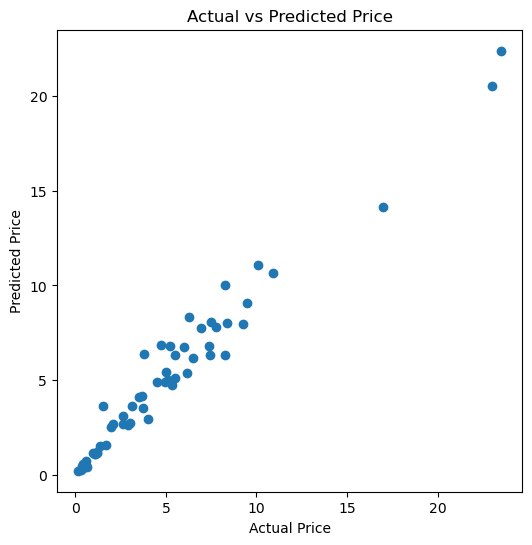

In [20]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_final)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()


## 19. Feature Importance

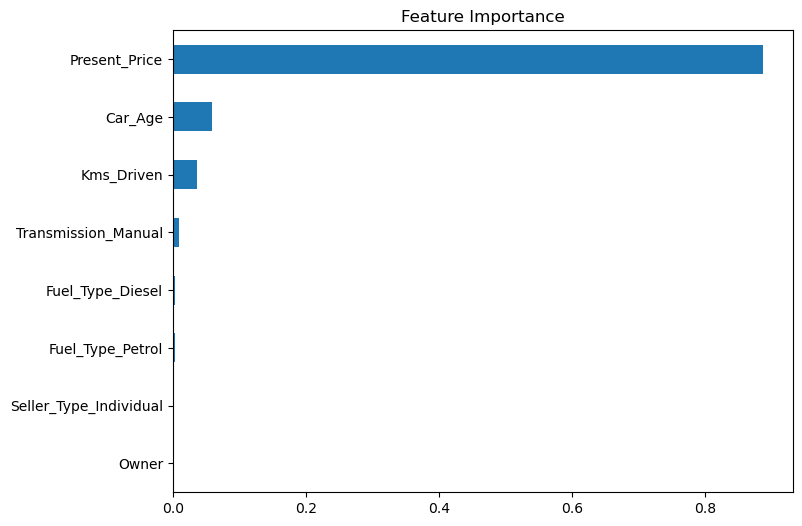

In [21]:

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance")
plt.show()


## It saves the trained model as car_price_model.pkl
This file will be used by the web application

In [22]:
import pickle

with open("car_price_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully")

Model saved successfully
